In [59]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [112]:
df = pd.read_csv("./data/df_filter_90k.csv")
df.head(5)

,Unidade da Federação,"Em geral, como o(a) Sr(a) avalia a sua saúde",Sexo,Idade do morador na data de referência,Cor ou raça,Qual é o estado civil de ___?,Sabe ler e escrever,Frequenta escola ou creche,Qual foi o curso mais elevado que ___frequentou,___concluiu este curso que frequentou,...,"Em quantos dias da semana o(a) Sr(a) costuma tomar leite? (de origem animal: vaca, cabra, búfala etc.)",Que tipo de leite o(a) Sr(a) costuma tomar?,"Em quantos dias da semana o(a) Sr(a) costuma comer alimentos doces como biscoito/bolacha recheado, chocolate, gelatina, balas e outros?","Em quantos dias da semana o(a) Sr(a) costuma substituir a refeição do almoço por lanches rápidos como sanduíches, salgados, pizza, cachorro quente, etc?","Considerando a comida preparada na hora e os alimentos industrializados, o(a) Sr(a) acha que o seu consumo de sal é:","Nos últimos três meses, o(a) Sr(a) praticou algum tipo de exercício físico ou esporte?",Com que frequência o(a) Sr(a) costuma consumir alguma bebida alcoólica?,Algum médico já lhe deu o diagnóstico de hipertensão arterial (pressão alta)?,Algum médico já lhe deu o diagnóstico de diabetes?,"Quando foi a última vez que o(a) Sr(a) fez exame de sangue para medir a glicemia, isto é, o açúcar no sangue?"
0,11,3,2,55,1,1,1,2,5.0,1.0,...,7,2.0,0,0,3,1,2,1.0,2.0,1
1,11,2,2,19,4,4,1,2,10.0,2.0,...,0,NaN,0,0,3,2,2,2.0,2.0,2
2,11,3,2,45,2,4,1,2,10.0,1.0,...,0,NaN,0,0,4,2,3,2.0,2.0,1
3,11,3,2,58,2,3,2,2,4.0,2.0,...,0,NaN,0,0,3,1,1,2.0,2.0,2
4,11,2,2,28,4,4,1,1,NaN,NaN,...,7,2.0,2,0,3,1,1,2.0,2.0,2


colocando a coluna target na 1 posicao

In [114]:
target_column = "Em geral, como o(a) Sr(a) avalia a sua saúde"


columns = list(df.columns)
columns.remove(target_column)
columns.insert(0, target_column)
df = df[columns]
df.head(5)

,"Em geral, como o(a) Sr(a) avalia a sua saúde",Unidade da Federação,Sexo,Idade do morador na data de referência,Cor ou raça,Qual é o estado civil de ___?,Sabe ler e escrever,Frequenta escola ou creche,Qual foi o curso mais elevado que ___frequentou,___concluiu este curso que frequentou,...,"Em quantos dias da semana o(a) Sr(a) costuma tomar leite? (de origem animal: vaca, cabra, búfala etc.)",Que tipo de leite o(a) Sr(a) costuma tomar?,"Em quantos dias da semana o(a) Sr(a) costuma comer alimentos doces como biscoito/bolacha recheado, chocolate, gelatina, balas e outros?","Em quantos dias da semana o(a) Sr(a) costuma substituir a refeição do almoço por lanches rápidos como sanduíches, salgados, pizza, cachorro quente, etc?","Considerando a comida preparada na hora e os alimentos industrializados, o(a) Sr(a) acha que o seu consumo de sal é:","Nos últimos três meses, o(a) Sr(a) praticou algum tipo de exercício físico ou esporte?",Com que frequência o(a) Sr(a) costuma consumir alguma bebida alcoólica?,Algum médico já lhe deu o diagnóstico de hipertensão arterial (pressão alta)?,Algum médico já lhe deu o diagnóstico de diabetes?,"Quando foi a última vez que o(a) Sr(a) fez exame de sangue para medir a glicemia, isto é, o açúcar no sangue?"
0,3,11,2,55,1,1,1,2,5.0,1.0,...,7,2.0,0,0,3,1,2,1.0,2.0,1
1,2,11,2,19,4,4,1,2,10.0,2.0,...,0,NaN,0,0,3,2,2,2.0,2.0,2
2,3,11,2,45,2,4,1,2,10.0,1.0,...,0,NaN,0,0,4,2,3,2.0,2.0,1
3,3,11,2,58,2,3,2,2,4.0,2.0,...,0,NaN,0,0,3,1,1,2.0,2.0,2
4,2,11,2,28,4,4,1,1,NaN,NaN,...,7,2.0,2,0,3,1,1,2.0,2.0,2


In [115]:
target = df.pop(target_column).to_numpy().tolist()


In [116]:
features = df.to_numpy().tolist()

In [117]:
type(target), type(features)

(list, list)

In [118]:
x_train, x_test, y_train, y_test = train_test_split(features,target, test_size=0.3, random_state=42)

In [119]:
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5, max_leaf_nodes=5)
dt_classifier.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,5
,min_impurity_decrease,0.0
,class_weight,None


In [120]:
y_pred = dt_classifier.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}, Quantidade de nos: {dt_classifier.tree_.node_count}, Qtd de Niveis: {dt_classifier.tree_.max_depth}")

Accuracy: 0.5421956410068247, Quantidade de nos: 9, Qtd de Niveis: 3


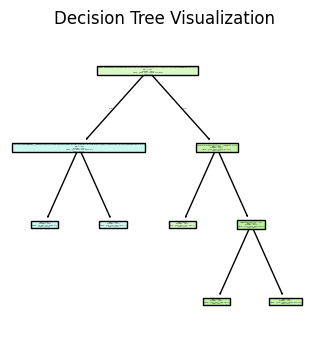

In [122]:
plt.figure(figsize=(4, 4))
plot_tree(dt_classifier, feature_names=df.columns.tolist(), class_names=['Muito Boa', 'Boa', "Regular", "Ruim", "Muito Ruim"], filled=True)
plt.title("Decision Tree Visualization")
plt.show()